In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

def get_real_samples(batch_size=1000):
    x = torch.empty(batch_size, 1).uniform_(-3.0, 3.0)
    y = -x
    return torch.cat([x, y], dim=1)

print("Real data shape:", get_real_samples(100).shape)

Real data shape: torch.Size([100, 2])


# GAN

In [2]:
class Generator(nn.Module):
    def __init__(self, latent_dim=1):
        super().__init__()
        self.value_layer = nn.Linear(latent_dim, 1)
        self.weight_layer = nn.Linear(latent_dim, 1)

    def forward(self, z):
        value = self.value_layer(z)
        weight = self.weight_layer(z)
        weighted_value = weight * value
        return torch.cat([weighted_value, -weighted_value], dim=1)

class Discriminator(nn.Module):
    def __init__(self, input_dim=2):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return torch.sigmoid(self.linear(x))

In [3]:
G = Generator(latent_dim=1)
D = Discriminator(input_dim=2)

optimizer_G = torch.optim.Adam(G.parameters(), lr=5e-4)
optimizer_D = torch.optim.Adam(D.parameters(), lr=5e-4)
loss_function = nn.BCELoss(reduction='sum')

real_labels = torch.ones(64, 1)
fake_labels = torch.zeros(64, 1)

epochs = 3000
batch_size = 64
real_dataset = get_real_samples(1000)

print("Starting GAN Training...")
for epoch in range(1, epochs + 1):
    idx = torch.randint(0, 1000, (batch_size,))
    real_batch = real_dataset[idx]

    z = torch.randn(batch_size, 1)
    fake_batch = G(z)

    d_loss_real = loss_function(D(real_batch), real_labels)
    d_loss_fake = loss_function(D(fake_batch.detach()), fake_labels)
    d_loss = d_loss_real + d_loss_fake

    optimizer_D.zero_grad()
    d_loss.backward()
    optimizer_D.step()

    z = torch.randn(batch_size, 1)
    fake_batch = G(z)
    
    g_loss = loss_function(D(fake_batch), real_labels)

    optimizer_G.zero_grad()
    g_loss.backward()
    optimizer_G.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | Discriminator Loss: {d_loss.item():.4f} | Generator Loss: {g_loss.item():.4f}")

print("GAN Training Complete.")

Starting GAN Training...
Epoch  500 | Discriminator Loss: 91.3708 | Generator Loss: 56.7498
Epoch 1000 | Discriminator Loss: 89.3632 | Generator Loss: 51.6936
Epoch 1500 | Discriminator Loss: 88.7212 | Generator Loss: 47.2480
Epoch 2000 | Discriminator Loss: 88.6972 | Generator Loss: 45.4217
Epoch 2500 | Discriminator Loss: 88.7134 | Generator Loss: 44.5653
Epoch 3000 | Discriminator Loss: 88.7204 | Generator Loss: 44.3967
GAN Training Complete.


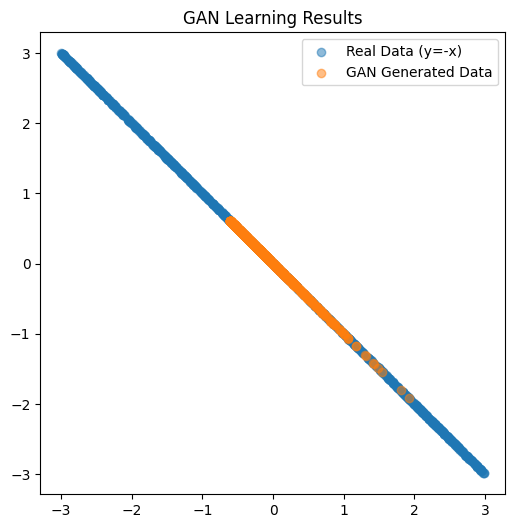

In [4]:
with torch.no_grad():
    noise = torch.randn(1000, 1)
    generated_points = G(noise)

real_points = get_real_samples(1000)

plt.figure(figsize=(6, 6))
plt.scatter(real_points[:, 0], real_points[:, 1], label="Real Data (y=-x)", alpha=0.5)
plt.scatter(generated_points[:, 0], generated_points[:, 1], label="GAN Generated Data", alpha=0.5)
plt.legend()
plt.title("GAN Learning Results")
plt.show()

# Diffusion

In [5]:
T = 100
beta = torch.linspace(0.0001, 0.02, T)
alpha = 1.0 - beta
alpha_bar = torch.cumprod(alpha, dim=0)

def add_noise(x0, t):
    noise = torch.randn_like(x0)
    a = alpha_bar[t].view(-1, 1)
    x_t = torch.sqrt(a) * x0 + torch.sqrt(1 - a) * noise
    return x_t, noise

In [6]:
class DiffusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 64),
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x, t):
        t_normalized = t.view(-1, 1) / T
        return self.net(torch.cat([x, t_normalized], dim=1))

In [7]:
diff_model = DiffusionModel()
diff_optimizer = torch.optim.Adam(diff_model.parameters(), lr=0.002)
mse_loss = nn.MSELoss()

print("Starting Diffusion Training...")
for epoch in range(1, 2001):
    x0 = get_real_samples(128)
    
    t = torch.randint(0, T, (128,))
    
    x_t, actual_noise = add_noise(x0, t)
    
    predicted_noise = diff_model(x_t, t)
    
    loss = mse_loss(predicted_noise, actual_noise)
    
    diff_optimizer.zero_grad()
    loss.backward()
    diff_optimizer.step()
    
    if epoch % 500 == 0:
        print(f"Epoch {epoch:4d} | MSE Loss: {loss.item():.4f}")
        
print("Diffusion Training Complete.")

Starting Diffusion Training...
Epoch  500 | MSE Loss: 0.4175
Epoch 1000 | MSE Loss: 0.3454
Epoch 1500 | MSE Loss: 0.4396
Epoch 2000 | MSE Loss: 0.3817
Diffusion Training Complete.


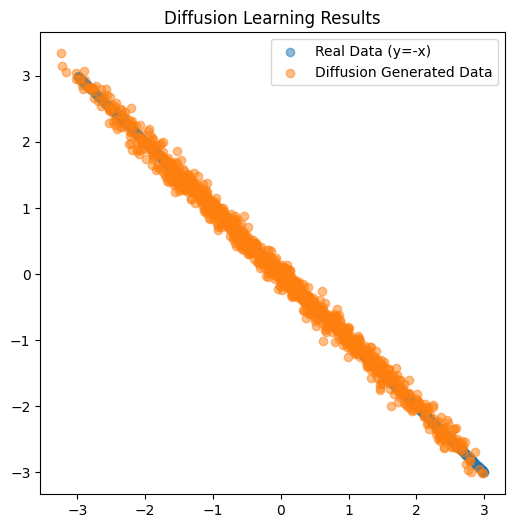

In [8]:
with torch.no_grad():
    x = torch.randn(1000, 2)
    
    for t in range(T - 1, -1, -1):
        t_tensor = torch.full((1000,), t)
        
        pred_noise = diff_model(x, t_tensor)
        
        a = alpha[t]
        a_bar = alpha_bar[t]
        b = beta[t]
        
        z = torch.randn_like(x) if t > 0 else 0
        
        x = (1 / torch.sqrt(a)) * (x - ((1 - a) / torch.sqrt(1 - a_bar)) * pred_noise) + torch.sqrt(b) * z

gen_data = x + torch.randn(1000, 2) * 0.08
real_data = get_real_samples(1000)

plt.figure(figsize=(6, 6))
plt.scatter(real_data[:, 0], real_data[:, 1], label="Real Data (y=-x)", alpha=0.5)
plt.scatter(gen_data[:, 0], gen_data[:, 1], label="Diffusion Generated Data", alpha=0.5)
plt.legend()
plt.title("Diffusion Learning Results")
plt.show()